In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 
import matplotlib as mpl

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

In [2]:
def draw_loglog_slope(fig, ax, origin, width_inches, slope, inverted=False, color=None, polygon_kwargs=None, label=True, labelcolor=None, label_kwargs=None, zorder=None):
    """
    This function draws slopes or "convergence triangles" into loglog plots.
    @param fig: The figure
    @param ax: The axes object to draw to
    @param origin: The 2D origin (usually lower-left corner) coordinate of the triangle
    @param width_inches: The width in inches of the triangle
    @param slope: The slope of the triangle, i.e. order of convergence
    @param inverted: Whether to mirror the triangle around the origin, i.e. whether 
        it indicates the slope towards the lower left instead of upper right (defaults to false)
    @param color: The color of the of the triangle edges (defaults to default color)
    @param polygon_kwargs: Additional kwargs to the Polygon draw call that creates the slope
    @param label: Whether to enable labeling the slope (defaults to true)
    @param labelcolor: The color of the slope labels (defaults to the edge color)
    @param label_kwargs: Additional kwargs to the Annotation draw call that creates the labels
    @param zorder: The z-order value of the triangle and labels, defaults to a high value
    """

    if polygon_kwargs is None:
        polygon_kwargs = {}
    if label_kwargs is None:
        label_kwargs = {}

    if color is not None:
        polygon_kwargs["color"] = color
    if "linewidth" not in polygon_kwargs:
        polygon_kwargs["linewidth"] = 0.75 * mpl.rcParams["lines.linewidth"]
    if labelcolor is not None:
        label_kwargs["color"] = labelcolor
    if "color" not in label_kwargs:
        label_kwargs["color"] = polygon_kwargs["color"]
    if "fontsize" not in label_kwargs:
        label_kwargs["fontsize"] = 0.75 * mpl.rcParams["font.size"]

    if inverted:
        width_inches = -width_inches
    if zorder is None:
        zorder = 10

    # For more information on coordinate transformations in Matplotlib see
    # https://matplotlib.org/3.1.1/tutorials/advanced/transforms_tutorial.html

    # Convert the origin into figure coordinates in inches
    origin_disp = ax.transData.transform(origin)
    origin_dpi = fig.dpi_scale_trans.inverted().transform(origin_disp)

    # Obtain the top-right corner in data coordinates
    corner_dpi = origin_dpi + width_inches * np.array([1.0, 0.0])
    corner_disp = fig.dpi_scale_trans.transform(corner_dpi)
    corner = ax.transData.inverted().transform(corner_disp)

    (x1, y1) = (origin[0], origin[1])
    x2 = corner[0]

    # The width of the triangle in data coordinates
    width = x2 - x1
    # Compute offset of the slope
    log_offset = y1 / (x1 ** (-slope))

    y2 = log_offset * (x2 ** (-slope))
    height = y2 - y1

    # The vertices of the slope
    a = origin
    b = corner
    c = [x2, y2]

    # Draw the slope triangle
    X = np.array([a, b, c])
    triangle = plt.Polygon(X[:3,:], fill=False, zorder=zorder, **polygon_kwargs)
    ax.add_patch(triangle)

    # Convert vertices into display space
    a_disp = ax.transData.transform(a)
    b_disp = ax.transData.transform(b)
    c_disp = ax.transData.transform(c)

    # Figure out the center of the triangle sides in display space
    bottom_center_disp = a_disp + 0.5 * (b_disp - a_disp)
    bottom_center = ax.transData.inverted().transform(bottom_center_disp)

    right_center_disp = b_disp + 0.5 * (c_disp - b_disp)
    right_center = ax.transData.inverted().transform(right_center_disp)

    # Label alignment depending on inversion parameter
    va_xlabel = "bottom" if not inverted else "top"
    ha_ylabel = "left" if not inverted else "right"

    # Label offset depending on inversion parameter
    offset_xlabel = [0.0, 0.33 * label_kwargs["fontsize"]] if not inverted else [0.0, -0.33 * label_kwargs["fontsize"]]
    offset_ylabel = [0.33 * label_kwargs["fontsize"], 0.0] if not inverted else [-0.33 * label_kwargs["fontsize"], 0.0]

    # Draw the slope labels
    ax.annotate("$1$", bottom_center, xytext=offset_xlabel, textcoords='offset points', ha="center", va=va_xlabel, zorder=zorder, **label_kwargs)
    ax.annotate(f"${slope}$", right_center, xytext=offset_ylabel, textcoords='offset points', ha=ha_ylabel, va="center", zorder=zorder, **label_kwargs)


In [3]:
def admissibility_split(MP, a, return_P=False, subspace=False, consistency = True, with_edges=False):
    level={1:5, 2:5, 3:5, 4:5, 5:5, 6:5, 7:5}
    marked = set()
    mapped = lambda x: 1 if x in (0, 1) else 0
    num_split=0
    assert isinstance(a,dict) and len(a)==len(MP.mesh.domains), 'Invalid type for diffusion coefficient'
    if return_P:
        P = scipy.sparse.identity(MP.nLocDofs)
    while True:
        for p in range(MP.mesh.numpatches):
            for b in range(4):
                kv = MP.mesh.kvs[p][mapped(b)]
                deg = kv.p
                s1,s2 = kv.support()
                nodes = np.clip(MP.mesh.boundaries(p)[1][b],kv.kv[0],kv.kv[-1])
                m = min(nodes[1:]-nodes[:-1])
                if not bspline_cy.pyx_checkSWcondition(kv.kv, kv.p, len(kv.kv), nodes, len(nodes), with_edges) or (s2-s1)/m>2**level[deg]-1:
                    marked.add(p)
        if consistency:
            for (p1,b1) in MP.mesh.L_intfs:
                if len(MP.mesh.L_intfs[(p1,b1)])>1:
                    p2 = MP.mesh.L_intfs[(p1,b1)][0][0]
                    if a[MP.mesh.patch_domains[p1]] + 1e-3 < a[MP.mesh.patch_domains[p2]]:
                        marked.add(p1)
        if len(marked)>0:
            num_split+=len(marked)
            if return_P:
                P = MP.h_refine({p:None for p in marked}, ref="rs", return_P=return_P, in_subspace=subspace) @ P
            else:
                MP.h_refine({p:None for p in marked}, ref="rs", return_P=return_P, in_subspace=subspace)
            marked=set()
        else:
            break
    if consistency:
        print("Split {} additional patches due to admissibility and consistency".format(num_split))
    else:
        print("Split {} additional patches due to admissibility".format(num_split))
    if return_P:
        return P

In [16]:
def Inductor(deg,N, airgap=0.025):
    kvs=42*[2*(bspline.make_knots(deg,0.0,1.0,N),)]
    
    geos=[      
        geometry.unit_square().scale((0.5)).translate((-0.5,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,-0.5)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,-0.5)),
        geometry.unit_square().scale(0.5).translate((1.5,-0.5)),
        
        geometry.unit_square().scale((0.5,0.25)).translate((-0.5,0)),
        geometry.unit_square().scale(0.25),
        geometry.unit_square().scale(0.25).translate((0.25,0)),
        geometry.unit_square().scale((0.5,0.25)).translate((0.5,0)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.,0)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.25,0)),
        geometry.unit_square().scale((0.5,0.25)).translate((1.5,0)),
        
        geometry.unit_square().scale((0.5,airgap)).translate((-0.5,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((0,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((0.25,0.25)),
        geometry.unit_square().scale((0.5,airgap)).translate((0.5,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((1.,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((1.25,0.25)),
        geometry.unit_square().scale((0.5,airgap)).translate((1.5,0.25)),
        
        geometry.unit_square().scale((0.5,0.5)).translate((-0.5,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,0.25+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,0.25+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((1.5,0.25+airgap)),
        
        geometry.unit_square().scale((0.5,0.25)).translate((-0.5,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((0,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((0.25,0.75+airgap)),
        geometry.unit_square().scale((0.5,0.25)).translate((0.5,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.25,0.75+airgap)),
        geometry.unit_square().scale((0.5,0.25)).translate((1.5,0.75+airgap)),
        
        geometry.unit_square().scale(0.5).translate((-0.5,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,1.0+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,1.0+airgap)),
        geometry.unit_square().scale(0.5).translate((1.5,1.0+airgap)),
         ]
    patches=list(zip(kvs,geos))
    M = topology.MultiPatch(patches)
    M.rename_domain(0,'Air')
    M.set_domain_id({'Fe':{8,9,10,11,12,22,24,26,29,30,31,32,33}, 'C1':{23}, 'C2':{25}})
    M.h_refine({i:1 for i in range(14,21)});                                        #split airgap patches further in y-axis to make up for anisotropy 
    M.h_refine({i:1 for i in list(range(14,21))+list(range(42,49))});               #split airgap patches further in y-axis to make up for anisotropy 
    #M.h_refine({i:1 for i in list(range(14,21))+list(range(42,49))+list(range(49,63))}); #split airgap patches further in y-axis to make up for anisotropy
    return M

In [17]:
mu0 = 4.344*np.pi*1e-7
nu = {'C1': 1/mu0, 'C2':1/mu0, 'Fe':1/(2500*mu0), 'Air': 1/mu0}
f = {'C1': lambda x,y: 66/(0.125), 'C2':lambda x,y: -66/(0.125), 'Fe':lambda x,y: 0.0, 'Air': lambda x,y: 0.0}
MaT = {'C1': lambda x,y: (0.,0.), 'C2': lambda x,y:(0.,0.), 'Fe':lambda x,y:(0.,0.), 'Air': lambda x,y:(0.,0.)}
dir_data = {0:0}
Keys = ['C1','C2','Fe','Air']

In [18]:
# M = Inductor(2,3, airgap=0.025)
# M.plotmesh(figsize=(20,20),color={'C1':'yellow', 'C2':'yellow', 'Fe':'gainsboro', 'Air':'white'}, knots=0, bwidth=0.01, patch_idx=0)
# r=0.08
# plt.gca().add_patch(plt.Circle((0.375, 0.5), r, fill=False))
# plt.plot(0.375, 0.5, 'o', color="black")
# plt.gca().add_patch(plt.Circle((1.125, 0.5), r, fill=False))
# plt.plot([1.125-r/np.sqrt(2), 1.125+r/np.sqrt(2)], [0.5+r/np.sqrt(2), 0.5-r/np.sqrt(2)], color="black")
# plt.plot([1.125-r/np.sqrt(2), 1.125+r/np.sqrt(2)], [0.5-r/np.sqrt(2),0.5+r/np.sqrt(2)], color="black")
# #plt.plot([0, 0], [-r, r])  # vertical
# plt.axis('off');
# plt.axis('scaled');
# #plt.show()
# plt.savefig('/home/wolfman/Pictures/Inductor_material_thin.pdf',bbox_inches='tight');

#########################################
setting up constraints took 0.15611624717712402 seconds.
Basis setup took 0.002521991729736328 seconds


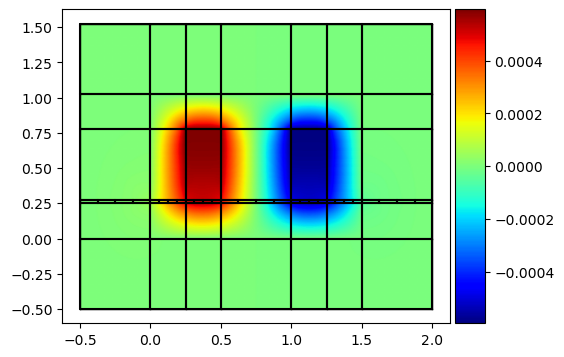

64.0695161638185
setting up constraints took 0.2686293125152588 seconds.
Basis setup took 0.003193378448486328 seconds


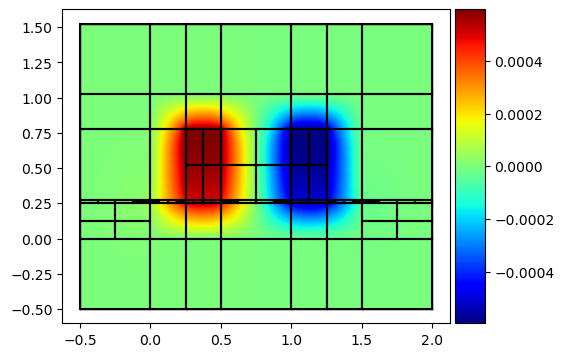

40.78167532003103
setting up constraints took 0.4404025077819824 seconds.
Basis setup took 0.004189491271972656 seconds


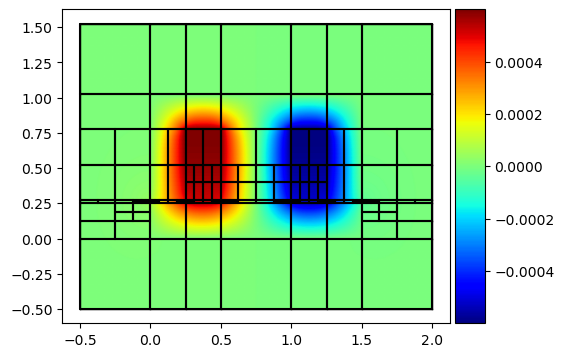

27.66664772524558
setting up constraints took 0.627941370010376 seconds.
Basis setup took 0.0052089691162109375 seconds


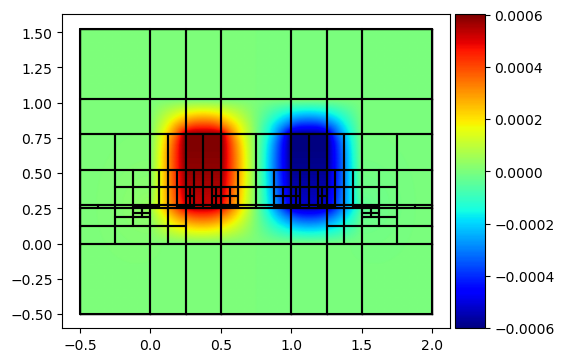

19.842506931536988
setting up constraints took 0.8369550704956055 seconds.
Basis setup took 0.005914211273193359 seconds


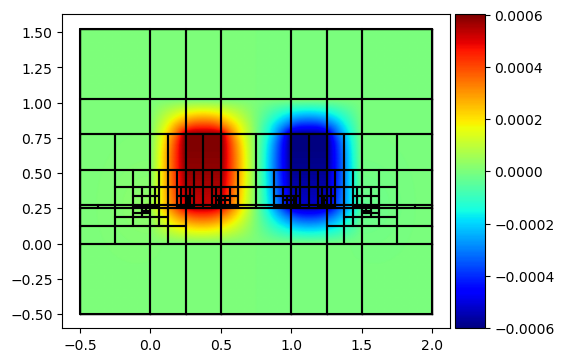

13.774013210306025
setting up constraints took 1.0972213745117188 seconds.
Basis setup took 0.006514310836791992 seconds


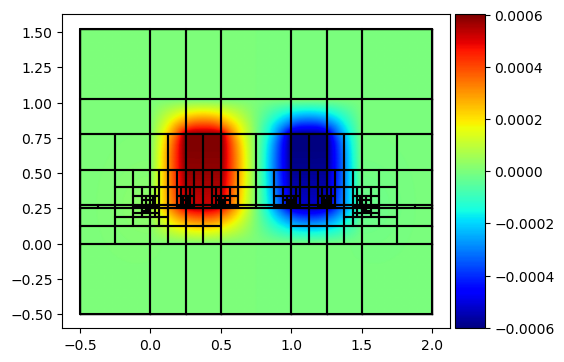

8.768267457084617
setting up constraints took 1.431800365447998 seconds.
Basis setup took 0.007743358612060547 seconds


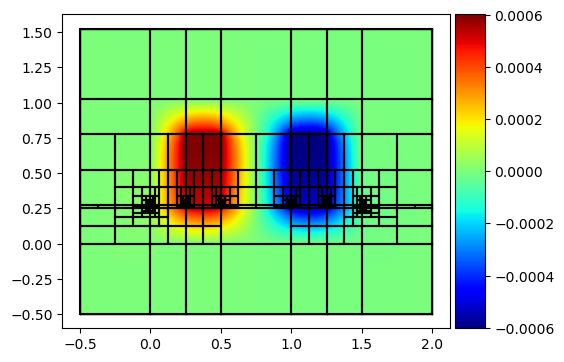

6.145776380611709
setting up constraints took 1.738142967224121 seconds.
Basis setup took 0.00893402099609375 seconds


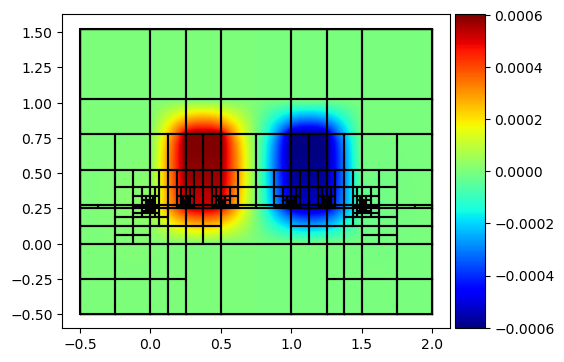

4.280731219974294
setting up constraints took 2.1612110137939453 seconds.
Basis setup took 0.010780096054077148 seconds


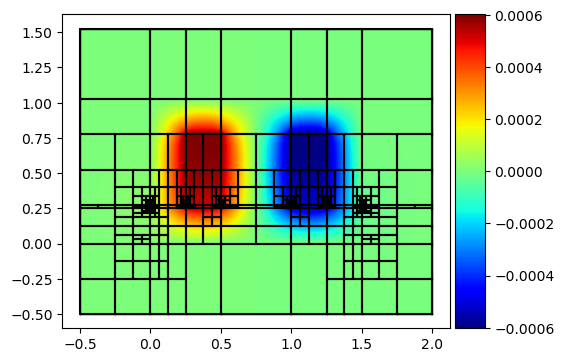

2.930090199967847
setting up constraints took 2.8020596504211426 seconds.
Basis setup took 0.013309240341186523 seconds


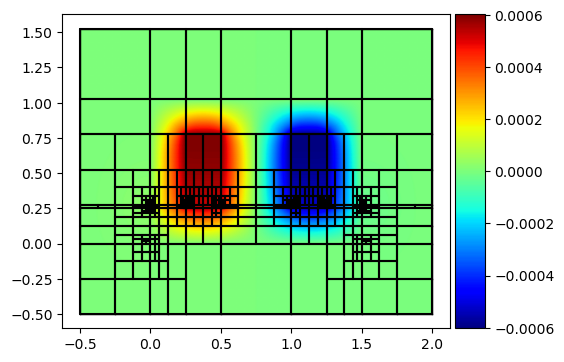

1.7302953087249557
setting up constraints took 3.4571890830993652 seconds.
Basis setup took 0.016531944274902344 seconds


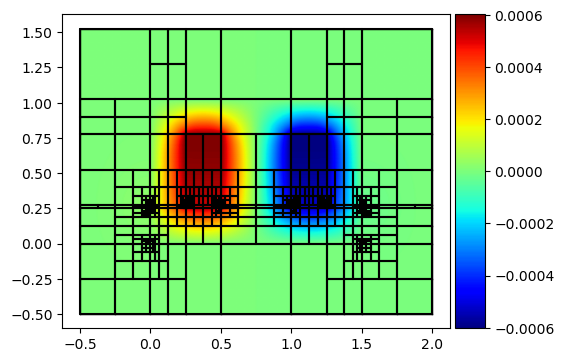

1.1287548661900861
setting up constraints took 4.252057313919067 seconds.
Basis setup took 0.021045684814453125 seconds


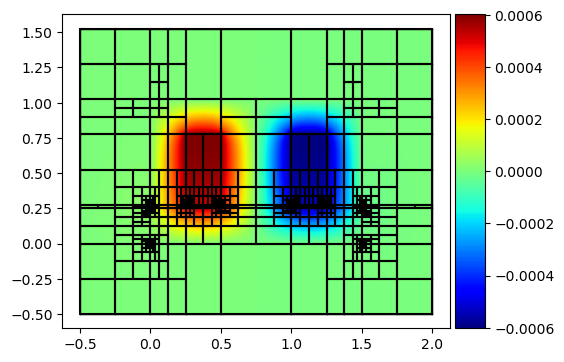

0.7237434522353515
setting up constraints took 5.290191411972046 seconds.
Basis setup took 0.024098634719848633 seconds


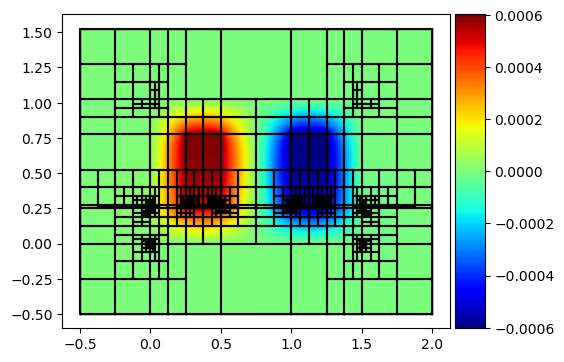

0.46787104395119516
setting up constraints took 6.7955663204193115 seconds.
Basis setup took 0.031085491180419922 seconds


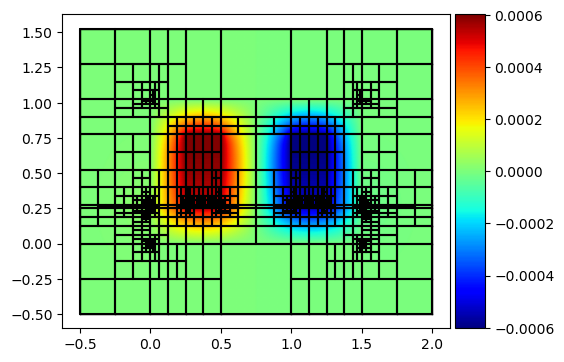

0.3054424564344445
setting up constraints took 9.007083892822266 seconds.
Basis setup took 0.04123401641845703 seconds


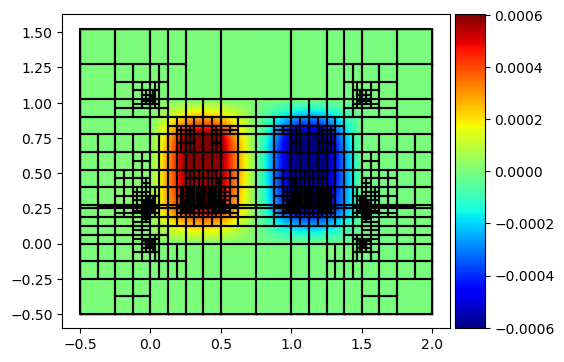

0.19327939822179274
setting up constraints took 11.900722742080688 seconds.
Basis setup took 0.05533862113952637 seconds


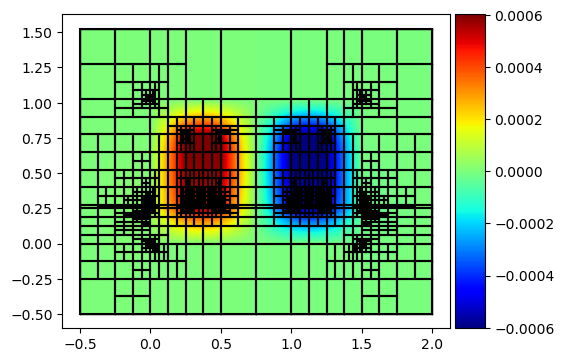

0.12454777379366841
setting up constraints took 12.842061996459961 seconds.
Basis setup took 0.12752366065979004 seconds
setting up constraints took 14.740794897079468 seconds.
Basis setup took 0.20682716369628906 seconds


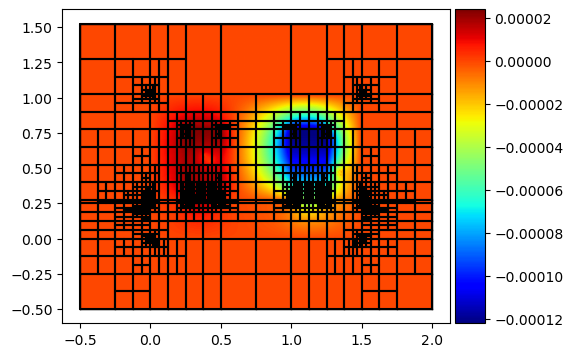

In [19]:
degs = (2,)
maxpatches =(5000,4000,3000,2000)
#maxiter=(7,7,7,6)
maxiter=(20,)
eps=(1e-3,1e-4,1e-5,1e-6)
plot=1
uniform=0

R = np.zeros((max(maxiter),len(degs)*5))

for i,deg in enumerate(degs):
    print("#########################################")
    N = deg+1
    M = Inductor(deg,N)

    MB = assemble.MultiBasis(M, subspace='C0')
    eta=1.0
    U=[]
    k=0
    while k<maxiter[i]:
        if plot:
            MB.mesh.plotmesh(figsize=(5,5),color={'C1':'yellow', 'C2':'yellow', 'Fe':'gainsboro', 'Air':'white'}, nodes=50, knots=1, bwidth=0.01, patch_idx=0)
            plt.axis('off');
            plt.axis('scaled');
            #plt.savefig('/mnt/c/Users/stefa/Pictures/Lshape/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
            plt.savefig('/home/wolfman/Pictures/Inductor/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
            #plt.show();
            plt.close();
            
        ### SOLVE
        R[k,i*5] = MB.nDofs
        R[k,i*5+1] = MB.nPatches
        
        dir_bcs = MB.set_fixed_boundary(dir_data)

        Kh = sum([MB.assemble_volume("nu*inner(grad(u),grad(v)) * dx", arity=2,nu=nu[k], domain_id=k) for k in Keys])
        Fh = np.sum([MB.assemble_volume("(f * v) * dx", arity=1, domain_id=k, f=f[k]) for k in Keys],axis=0)
        LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)
        uh = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)
        U.append(uh)
            
        MB.plot(uh, mesh=True)
        plt.show();

        if not uniform:
            err_ind=adaptive.mp_resPois(MB, uh, nu=nu, f=f)
            eta = np.linalg.norm(err_ind)
            R[k,i*5+3] = eta

        # print(Eerr)
        print(eta)
        # print(eta/Eerr)
        if not uniform:
            marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
            marked_patches = {p:None for p in marked_patches}
    
            if MB.nPatches + 3*len(marked_patches) >= maxpatches[i]:
                break;

        if eta < eps[i]:
            break;

        if not uniform:
            P = MB.h_refine(h_ref=marked_patches,ref="rs", return_P = True, in_subspace=True)
        else:
            P = MB.h_refine(h_ref=-1,ref="rs", return_P = True, in_subspace=True)

        for j in range(len(U)):
            U[j]=P@U[j]
        k+=1
        
    P = MB.h_refine(h_ref=-1,ref="rs", return_P = True, in_subspace=True)
    P = MB.p_refine(1, return_P = True, in_subspace=True)@P

    Kh = sum([MB.assemble_volume("nu*inner(grad(u),grad(v)) * dx", arity=2,nu=nu[k], domain_id=k) for k in Keys])
    Fh = np.sum([MB.assemble_volume("(f * v) * dx", arity=1, domain_id=k, f=f[k]) for k in Keys], axis=0)
    LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)

    u_exact = LS.complete(operators.make_solver(LS.A,spd=True)@LS.b)

    MB.plot(u_exact, mesh=True)
    plt.show();

    for j in range(len(U)):
        eh = u_exact - P@U[j]
        Eerr = np.sqrt(eh@Kh@eh)
        R[j,i*5+2] = Eerr
        R[j,i*5+4] = R[j,i*5+3]/Eerr
        
    if uniform:
        np.save('Inductor_uniform_p'+str(deg),R)
    else:
        np.save('Inductor_adaptive_p'+str(deg),R)

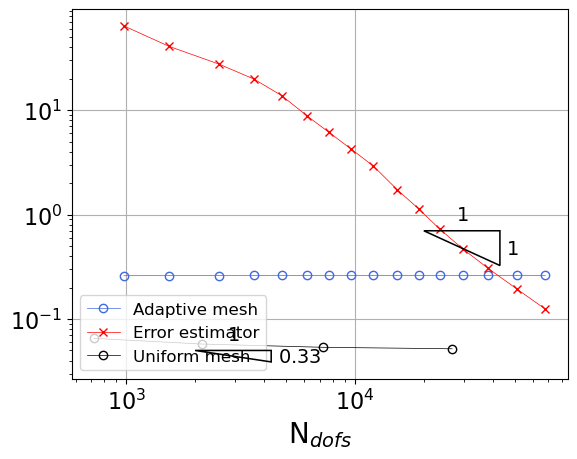

In [26]:
#R_a = np.load('Inductor_adaptive.npy')
#R_u = np.load('Inductor_uniform.npy')

# numdofs=R_u[:,0]
# # numdofs_a = R_a[:,0]
# Eerr = R_u[:,2]
# # Eerr_a = R_a[:,2]
pos=((2*1e4,7*1e-1),(2.5*1e4,3*1e-5),(5*1e4,5*1e-7),(6*1e4,1e-7))
pos_u=((2*1e3,5*1e-2),(4*1e3,3*1e-3),(1e4,1.5*1e-3),(3*1e3,1e-3))
w = (1.5,1.5,1.5,1.5)
inv = (False,False,False,True)
for i, deg in enumerate((2,)):
    R_a = np.load('Inductor_adaptive_p'+str(deg)+'.npy')
    R_u = np.load('Inductor_uniform_p'+str(deg)+'.npy')
    numdofs=R_u[:,0]
    numdofs_a = R_a[:,0]
    Eerr = R_u[:,2]
    Eerr_a = R_a[:,2]
    Eta = R_a[:,3]

    numdofs=numdofs[numdofs!=0]
    numdofs_a=numdofs_a[numdofs_a != 0]
    Eerr_a = Eerr_a[Eerr_a!=0]
    Eerr = Eerr[Eerr!=0]
    Eta = Eta[Eta!=0]
    
    fig, ax = plt.subplots()
    plt.loglog(numdofs_a, Eerr_a, 'o-',color='royalblue',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs_a, Eta, 'x-',color='red',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs, Eerr, 'o-',color='black',linewidth=0.5, markerfacecolor='none')
    plt.grid('True');
    ax.tick_params(axis='both', labelsize=16)
    plt.legend(['Adaptive mesh','Error estimator','Uniform mesh'],loc='lower left',prop={'size': 12})
    plt.xlabel("N$_{dofs}$",size=20)
    draw_loglog_slope(fig,ax,pos[i],w[i],slope=int(deg/2) if deg%2==0 else deg/2,inverted=inv[i], color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)
    draw_loglog_slope(fig,ax,pos_u[i],w[i],0.33,inverted=inv[i], color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)

    plt.savefig('Inductorp'+str(deg)+'n'+str(deg+1)+'H1_cnv.pdf', bbox_inches='tight')
    plt.show()
    

In [28]:
MB.nPatches

4509